In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tabulate
import wandb

from tqdm import tqdm

api = wandb.Api(timeout=60)

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.0)

In [ ]:
sweeps = {
    # New sweeps   (navigate, geometric_shapes, snarks, temporal_sequences, object_counting)
    # "Qwen3 0.6B, 1.7B": "ipzfwru9",  # in `results/new-sweeps.csv`
    # "Qwen3 4B": "qik51jis",  # in `results/new-sweeps.csv`

    # Sports Understanding / explore
    "Sports Understanding / Qwen-3 0.6B": "ijd4ys98",
    "Sports Understanding / Qwen-3 1.7B": "i96mfs3b",
    "Sports Understanding / Qwen-3 4B": "5ovplf4r",
    
    # Navigate
    # "Navigate / Qwen-3 0.6B": "cl6ivblf",  # "1mj4cf3y", 
    # "Navigate / Qwen-3 1.7B": "ismk05rl",  #  "s5nmb0av",
    # "Navigate / Qwen-3 4B": "q53h0udp",
    # Geometric Shapes
    # "Geometric Shapes / Qwen-3 0.6B": "pga5mf78",
    # "Geometric Shapes / Qwen-3 1.7B": "q1w5zj6y",
    # "Geometric Shapes / Qwen-3 4B": "x5ig7l0y",  # ICL+FT
    # Object Counting
    # "Object Counting / Qwen-3 1.7B": "oiglal1g",
    # "Object Counting / Qwen-3 0.6B": "yl3kpass",
    # "Object Counting / Qwen-3 4B": "0f6svdzq",    
    # Temporal Sequences
    # "Temporal Sequences / Qwen-3 0.6B": "",
    # "Temporal Sequences / Qwen-3 1.7B": "",
    # Sports Understanding
    # "Sports Understanding / Qwen-3 0.6B": "4ao79iz7",
    # "Sports Understanding / Qwen-3 1.7B": "t3net9b0",
    # "Sports Understanding / Qwen-3 4B": "7qo8wz3g",
    # Snarks
    # "Snarks / Qwen-3 0.6B": "2vr05s0n",  
    # "Snarks / Qwen-3 1.7B": "u7ox4ez3",
    # "Snarks / Qwen-3 4B": "rdgmu1px",
}

all_dfs = []
for sweep_name, sweep_id in tqdm(sweeps.items()):
    sweep = api.sweep(f"j-bornschein/ficl/{sweep_id}")
    runs = sweep.runs

    for r in tqdm(runs):
        df = r.history(keys=['pos', 'test_accuracy', 'avg_accuracy'])
        # df = df.drop(columns=['_step'])
        df['sweep_id'] = sweep_id
        df['sweep_name'] = sweep_name
        df['run_id'] = r.id
        df['run_name'] = r.name
        for k, v in r.config.items():
            df[k] = v
        all_dfs.append(df)
df = pd.concat(all_dfs, ignore_index=True)


100%|██████████| 3/3 [07:22<00:00, 147.35s/it]


In [ ]:
# new-sweeps is 
#   "Qwen3 0.6B, 1.7B": "ipzfwru9",
#   "Qwen3 4B": "qik51jis",
# df.to_csv("new-sweeps.csv")

In [101]:
# Get the best row (highest avg_accuracy) for each group
idx = df.groupby(['dataset', 'model_name', 'num_context', 'pos', 'random_seed'])['avg_accuracy'].idxmax()
best_rows = df.loc[idx]
len(best_rows), len(idx) 


KeyError: 'num_context'

In [100]:


best_rows['model_name'] = best_rows['model_name'].map({
    'Qwen/Qwen3-0.6B': 'Qwen3 0.6B',
    'Qwen/Qwen3-1.7B': 'Qwen3 1.7B',
    'Qwen/Qwen3-4B': 'Qwen3 4B',
})

best_rows['method'] = best_rows['num_context'].map({
    0: 'FT',
    3: 'ICL+FT',
})

best_rows

best_rows.groupby(['model_name', 'pos', 'learning_rate']).count()


,,,_step,test_accuracy,avg_accuracy,sweep_id,sweep_name,run_id,run_name,dataset,test_pos,optimizer,num_epochs,instruction,num_context,random_seed,max_sample_tokens,num_test_examples,num_train_examples,method
model_name,pos,learning_rate,,,,,,,,,,,,,,,,,,


In [99]:
df.learning_rate.unique()

AttributeError: 'DataFrame' object has no attribute 'learning_rate'

In [75]:
def my_palette():
    a = sns.color_palette("tab10")
    return sns.color_palette(a[:1] + a[2:0:-1] + a[3:])


sns.set_palette(my_palette())
my_palette()

[(0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 (1.0, 0.4980392156862745, 0.054901960784313725),
 (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 (0.5803921568627451, 0.403921568627451, 0.7411764705882353),
 (0.5490196078431373, 0.33725490196078434, 0.29411764705882354),
 (0.8901960784313725, 0.4666666666666667, 0.7607843137254902),
 (0.4980392156862745, 0.4980392156862745, 0.4980392156862745),
 (0.7372549019607844, 0.7411764705882353, 0.13333333333333333),
 (0.09019607843137255, 0.7450980392156863, 0.8117647058823529)]

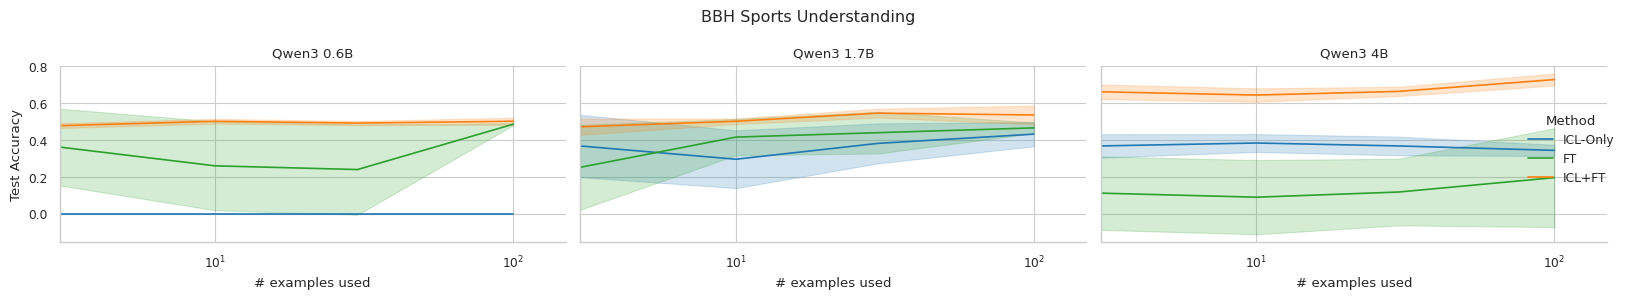

In [98]:
sns.set_context("paper")
sns.set_style("whitegrid")

g = sns.FacetGrid(
    data=pd.concat([icl_df, best_rows]),
    aspect=1.7, height=3, sharey=True,
    col_wrap=3, palette=my_palette(),
    col="model_name",
    # row="dataset",
    hue='method',
    margin_titles=True,
)

g.map_dataframe(
    sns.lineplot, 
    x="pos", y="test_accuracy", 
    errorbar=("sd", 1)
)
g.figure.subplots_adjust(top=0.85) # Adjust 'top' value as needed
g.figure.suptitle("BBH Sports Understanding")

g.set(xscale="log", xlim=(3, 150), xlabel="# examples used")
g.set(ylabel="Test Accuracy")
g.set_titles(template="{col_name}")
g.add_legend(title="Method") # , loc="lower left") # , bbox_to_anchor=(0.68, 0.05)) # , 0.3, 1/8))
plt.tight_layout()
plt.savefig("sports-understanding-qwen3.png")

<Axes: xlabel='pos', ylabel='avg_accuracy'>

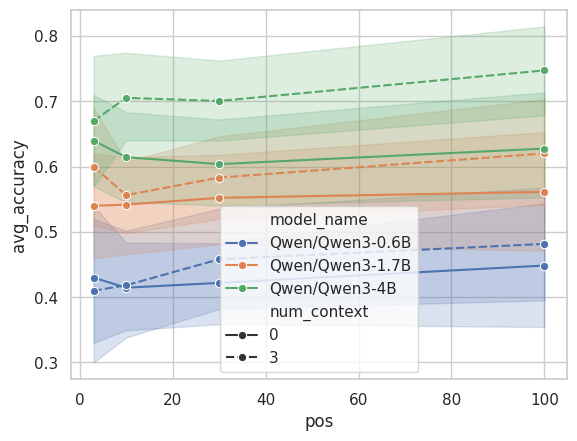

In [7]:
sns.lineplot(
    data=best_rows,
    x='pos', y='avg_accuracy', 
    hue='model_name',
    style='num_context',
    marker='o'
    )

In [13]:
table = best_rows.copy()
table['size'] = table['model_name'].str.split('-').str[1]
table['iclft'] = table['num_context'] > 0
table['test_accuracy'] = (table['test_accuracy'] * 100).round(0).astype(int)

# Create a pivot table for markdown formatting
table = table.pivot_table(
    index='pos',
    columns=['size', 'iclft'],
    values='test_accuracy',
    aggfunc='first'
)
print(table.to_markdown())

|   pos |   ('0.6B', False) |   ('0.6B', True) |   ('1.7B', False) |   ('1.7B', True) |   ('4B', False) |   ('4B', True) |
|------:|------------------:|-----------------:|------------------:|-----------------:|----------------:|---------------:|
|     3 |                34 |               45 |                50 |               50 |              56 |             59 |
|    10 |                44 |               42 |                53 |               49 |              47 |             59 |
|    30 |                50 |               46 |                54 |               52 |              47 |             66 |


In [8]:
for gname, gdf in df.groupby(['dataset', 'model_name', 'num_context', 'pos']):
    print("=" * 78)
    # print(gname)
    print(len(gdf))
    idx = gdf.avg_accuracy.idxmax()
    print(idx)
    # print(gdf.iloc[idx])
    # break


15
4
15
13
15
14
15
15
15
20
15
73
15
34
15
35
15
128
15
177
15
210
15
215
15
180
15
193
15
194
15
239
10
240
10
245
10
250
10
251
10
260
10
261
10
262
10
263


In [9]:
# r.history()
# r.config

df = r.history(keys=['pos', 'test_accuracy', 'avg_accuracy'])

In [10]:
for k, v in r.config.items():
    df[k] = v
# df?

In [11]:
# Create a pivot table for markdown formatting
pivot_table = best_rows.pivot_table(
    index='pos',
    columns=['model_name', 'num_context'],
    values='avg_accuracy',
    aggfunc='first'
)

# Get unique model names and num_context values
model_names = sorted(pivot_table.columns.get_level_values(0).unique())
num_contexts = sorted(pivot_table.columns.get_level_values(1).unique())

# Create markdown table with two-level column headers
# First row: model names (repeated for each num_context)
print("| pos |", end="")
for model in model_names:
    for num_ctx in num_contexts:
        if (model, num_ctx) in pivot_table.columns:
            print(f" {model} |", end="")
print()

# Second row: num_context values
print("| --- |", end="")
for model in model_names:
    for num_ctx in num_contexts:
        if (model, num_ctx) in pivot_table.columns:
            print(" --- |", end="")
print()

print("| |", end="")
for model in model_names:
    for num_ctx in num_contexts:
        if (model, num_ctx) in pivot_table.columns:
            print(f" {num_ctx} |", end="")
print()

# Data rows
for pos in sorted(pivot_table.index):
    print(f"| {pos} |", end="")
    for model in model_names:
        for num_ctx in num_contexts:
            if (model, num_ctx) in pivot_table.columns:
                value = pivot_table.loc[pos, (model, num_ctx)]
                if pd.notna(value):
                    print(f" {value:.4f} |", end="")
                else:
                    print(" - |", end="")
    print()


| pos | Qwen/Qwen3-0.6B | Qwen/Qwen3-0.6B | Qwen/Qwen3-1.7B | Qwen/Qwen3-1.7B | Qwen/Qwen3-4B | Qwen/Qwen3-4B |
| --- | --- | --- | --- | --- | --- | --- |
| | 0 | 2 | 0 | 3 | 0 | 3 |
| 3 | 0.5000 | 0.5000 | 0.5000 | 0.5000 | 0.7500 | 1.0000 |
| 10 | 0.6364 | 0.6364 | 0.6364 | 0.5455 | 0.8182 | 0.9091 |
| 30 | 0.6774 | 0.6452 | 0.6452 | 0.5806 | 0.7097 | 0.7419 |
| 100 | 0.6040 | 0.5842 | 0.5842 | 0.6139 | 0.5842 | 0.7030 |


## Load ICL-Only



In [69]:
sweeps = {
    "Sports Understanding / ICL-Only": "whexrlem",
}


all_dfs = []
for sweep_name, sweep_id in tqdm(sweeps.items()):
    sweep = api.sweep(f"j-bornschein/ficl/{sweep_id}")
    runs = sweep.runs

    for r in tqdm(runs):
        df = r.history(keys=['pos', 'accuracy'])
        # df = df.drop(columns=['_step'])
        df['sweep_id'] = sweep_id
        df['sweep_name'] = sweep_name
        df['run_id'] = r.id
        df['run_name'] = r.name
        for k, v in r.config.items():
            df[k] = v
        all_dfs.append(df)
icl_df = pd.concat(all_dfs, ignore_index=True)


100%|██████████| 1/1 [00:08<00:00,  8.51s/it]


In [103]:
icl_df = pd.concat(all_dfs, ignore_index=True)

# icl_df['model_name'] = icl_df['model_name'].map({
#     'qwen3-0.6b': 'Qwen3 0.6B',
#     'qwen3-1.7b': 'Qwen3 1.7B',
#     'qwen3-4b': 'Qwen3 4B',
# })
icl_df['method'] = 'ICL-Only'

icl_df['test_accuracy'] = icl_df['accuracy']



In [104]:
# icl_df = pd.concat(all_dfs, ignore_index=True)

icl_df['model_name'].unique()

array(['qwen3-0.6b', 'qwen3-1.7b', 'qwen3-4b', 'qwen3-30b'], dtype=object)

In [109]:
icl_df.groupby(['model_name']).accuracy.sem()

model_name
qwen3-0.6b    0.000000
qwen3-1.7b    0.029213
qwen3-30b     0.008489
qwen3-4b      0.010721
Name: accuracy, dtype: float64